## Setup: Import Libraries

Import all necessary libraries for the analysis.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from scipy.stats import skew


# Classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---

## Part A: Data Exploration and Preprocessing

### Task A1: Initial Exploration (5 marks)

**Note:** You have been provided with your unique dataset file. Load it below.

In [2]:
# Load your unique dataset
# The file name should match: assessment_data_[YOUR_STUDENT_ID].csv
# Replace [YOUR_STUDENT_ID] with your actual student ID

import os

# Example: If your student ID is 12345678, the file is: assessment_data_12345678.csv
student_id = "30260942"  # Replace with your actual student ID
dataset_file = f"assessment_data_{student_id}.csv"

# Check if file exists
if os.path.exists(dataset_file):
    df = pd.read_csv(dataset_file)
    print(f"✓ Dataset loaded successfully: {dataset_file}")
    print(f"Shape: {df.shape}")
else:
    print(f"❌ Error: File '{dataset_file}' not found!")
    print("Please ensure your dataset file is in the same directory as this notebook.")

✓ Dataset loaded successfully: assessment_data_30260942.csv
Shape: (600, 9)


In [3]:
# Display first few rows
df.head()

,temperature,humidity,soil_moisture,pH_level,nitrogen,phosphorus,potassium,light_intensity,crop_health
0,23.75,62.5,66.5,5.64,65.3,16.9,50.1,3654.0,Poor
1,29.85,77.6,32.3,6.85,32.0,23.7,30.3,4524.0,Fair
2,21.58,72.2,55.7,5.21,94.8,25.1,54.0,7293.0,Excellent
3,25.91,63.9,68.5,5.96,46.4,8.6,55.9,3535.0,Good
4,23.34,58.1,56.5,6.43,52.8,24.5,53.2,5952.0,Poor


In [4]:
# Dataset dimensions and structure
print("Dataset Information:")
print("=" * 60)
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")  # Excluding target
print(f"\nFeatures:")
for col in df.columns[:-1]:
    print(f"  - {col}: {df[col].dtype}")
print(f"\nTarget variable: crop_health")

Dataset Information:
Number of samples: 600
Number of features: 8

Features:
  - temperature: float64
  - humidity: float64
  - soil_moisture: float64
  - pH_level: float64
  - nitrogen: float64
  - phosphorus: float64
  - potassium: float64
  - light_intensity: float64

Target variable: crop_health


In [5]:
# Summary statistics
df.describe()

,temperature,humidity,soil_moisture,pH_level,nitrogen,phosphorus,potassium,light_intensity
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,24.370233,68.003167,54.850500,6.085867,51.692167,23.617333,41.307667,5180.168333
std,3.823198,10.035435,11.028972,0.506953,16.261452,10.187689,12.338122,1802.584685
min,10.240000,30.000000,23.200000,5.000000,10.000000,5.000000,10.000000,1000.000000
25%,21.617500,62.500000,46.100000,5.750000,39.600000,16.250000,32.850000,3884.500000
50%,24.260000,68.750000,55.300000,6.070000,51.850000,22.400000,41.550000,5102.000000
75%,27.240000,75.125000,63.500000,6.380000,63.750000,30.200000,50.125000,6454.000000
max,35.000000,90.000000,80.000000,8.000000,100.000000,50.000000,80.000000,10000.000000


In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
temperature        0
humidity           0
soil_moisture      0
pH_level           0
nitrogen           0
phosphorus         0
potassium          0
light_intensity    0
crop_health        0
dtype: int64

Total missing values: 0


In [7]:
# Target variable distribution
print("Crop Health Distribution:")
print(df['crop_health'].value_counts())
print(f"\nClass proportions:")
print(df['crop_health'].value_counts(normalize=True))

Crop Health Distribution:
crop_health
Poor         154
Fair         150
Excellent    150
Good         146
Name: count, dtype: int64

Class proportions:
crop_health
Poor         0.256667
Fair         0.250000
Excellent    0.250000
Good         0.243333
Name: proportion, dtype: float64


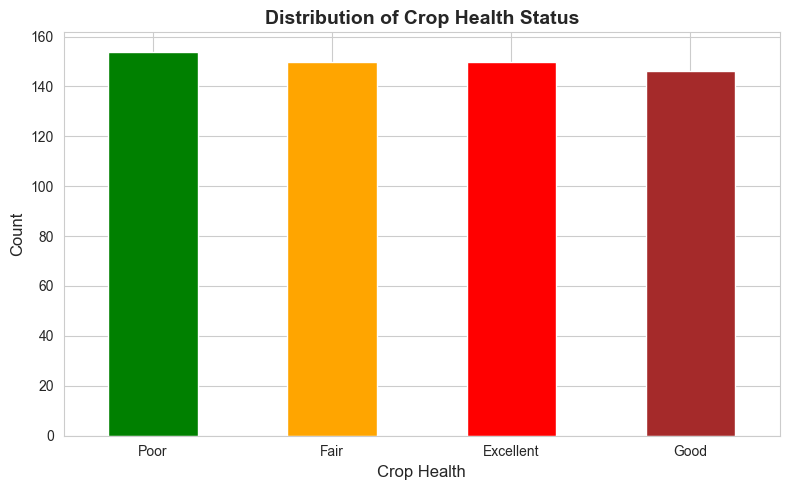

In [8]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
df['crop_health'].value_counts().plot(kind='bar', color=['green', 'orange', 'red', 'brown'])
plt.title('Distribution of Crop Health Status', fontsize=14, fontweight='bold')
plt.xlabel('Crop Health', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

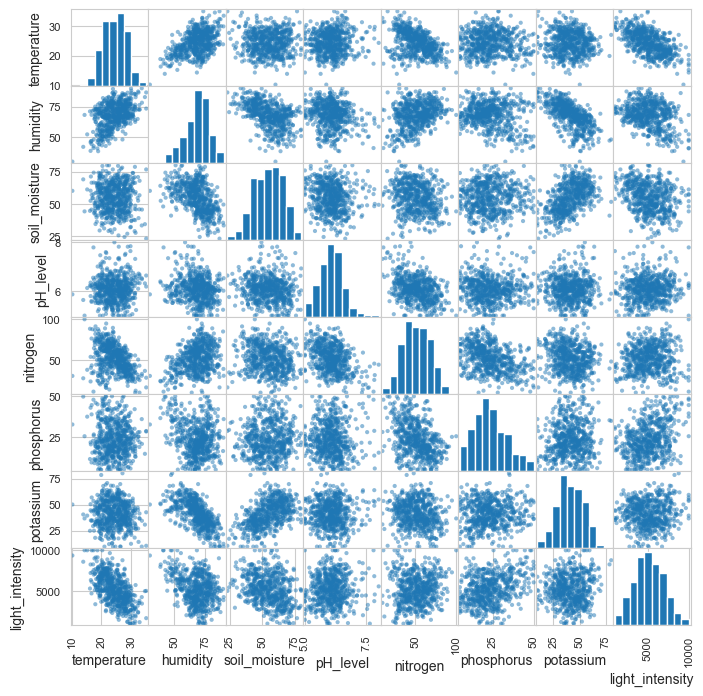

In [9]:
pd.plotting.scatter_matrix(df, figsize=(8,8))
plt.show()

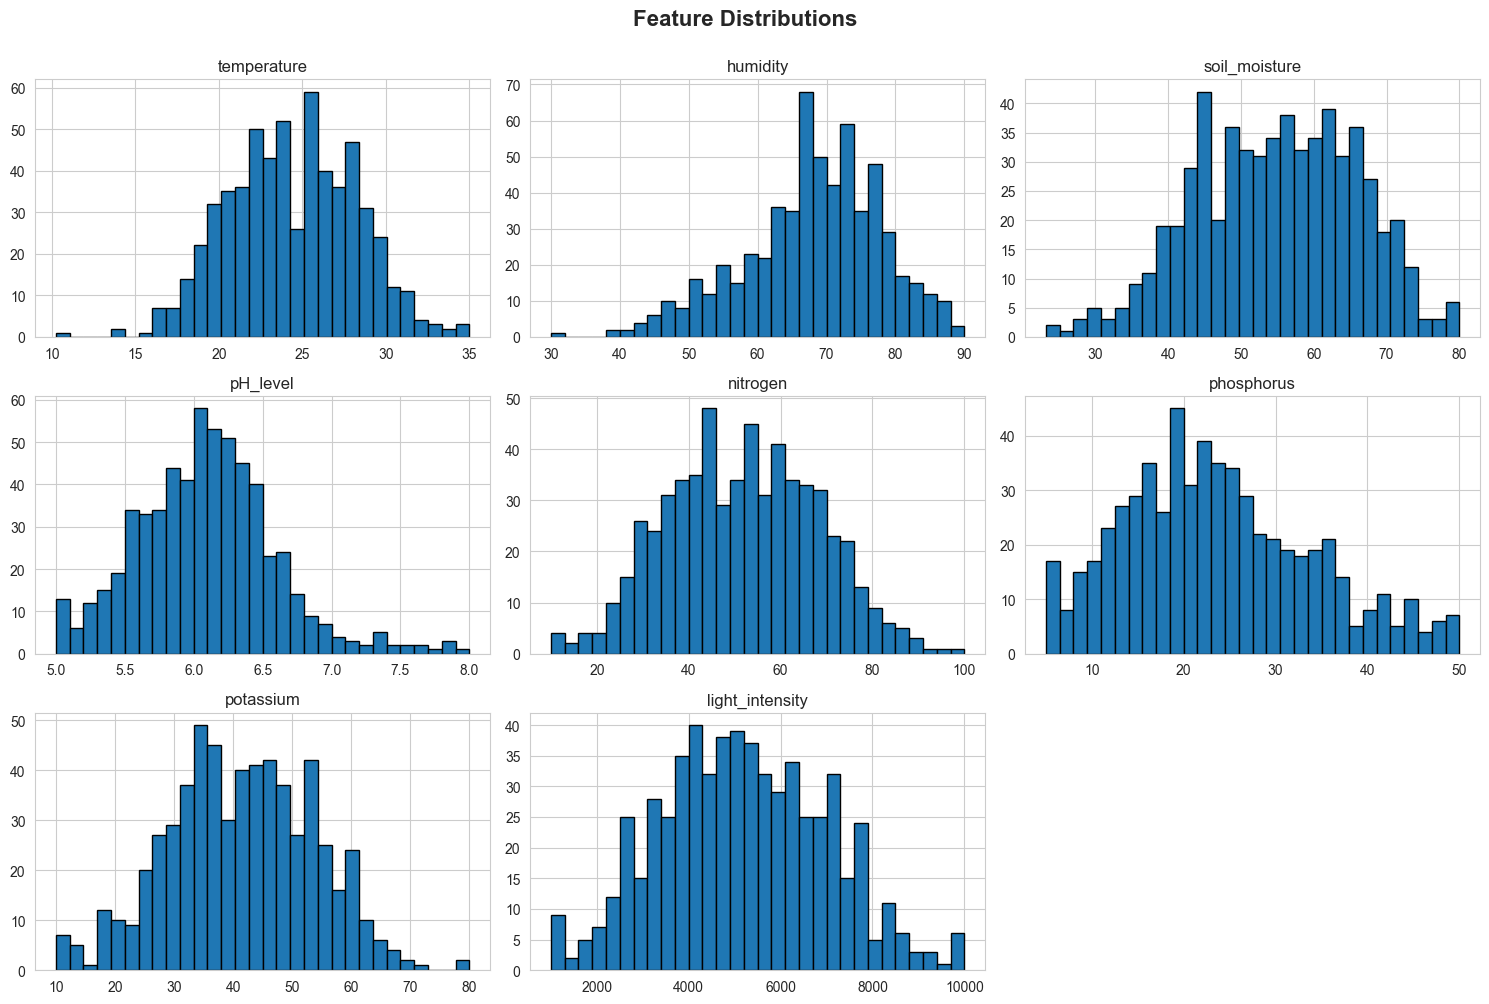

In [10]:
# Feature distributions - histograms
df.iloc[:, :-1].hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

#plt.figure(figsize=(15, 10))
#for i, col in enumerate(df.columns[:-1]):
#    plt.subplot(3, 3, i + 1)
#    df[col].hist(bins=30, edgecolor='black')
#    skew_val = skew(df[col])
#    plt.title(f'{col}\nSkewness: {skew_val:.2f}', fontsize=12, fontweight='bold')
#    plt.xlabel(col)
#    plt.ylabel('Frequency')
#    plt.grid(True, alpha=0.3)

#plt.suptitle('Feature Distributions with Skewness', fontsize=16, fontweight='bold', y=1.02)
#plt.tight_layout()
#plt.show()


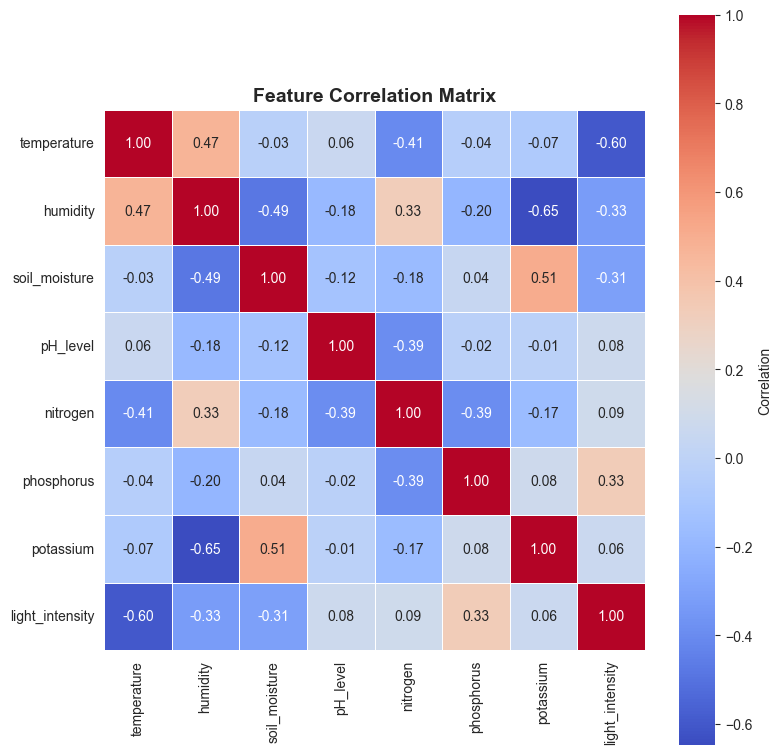


Highly Correlated Feature Pairs (|r| > 0.7):


In [11]:
# Correlation matrix
plt.figure(figsize=(8, 8))
correlation_matrix = df.iloc[:, :-1].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated features
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")

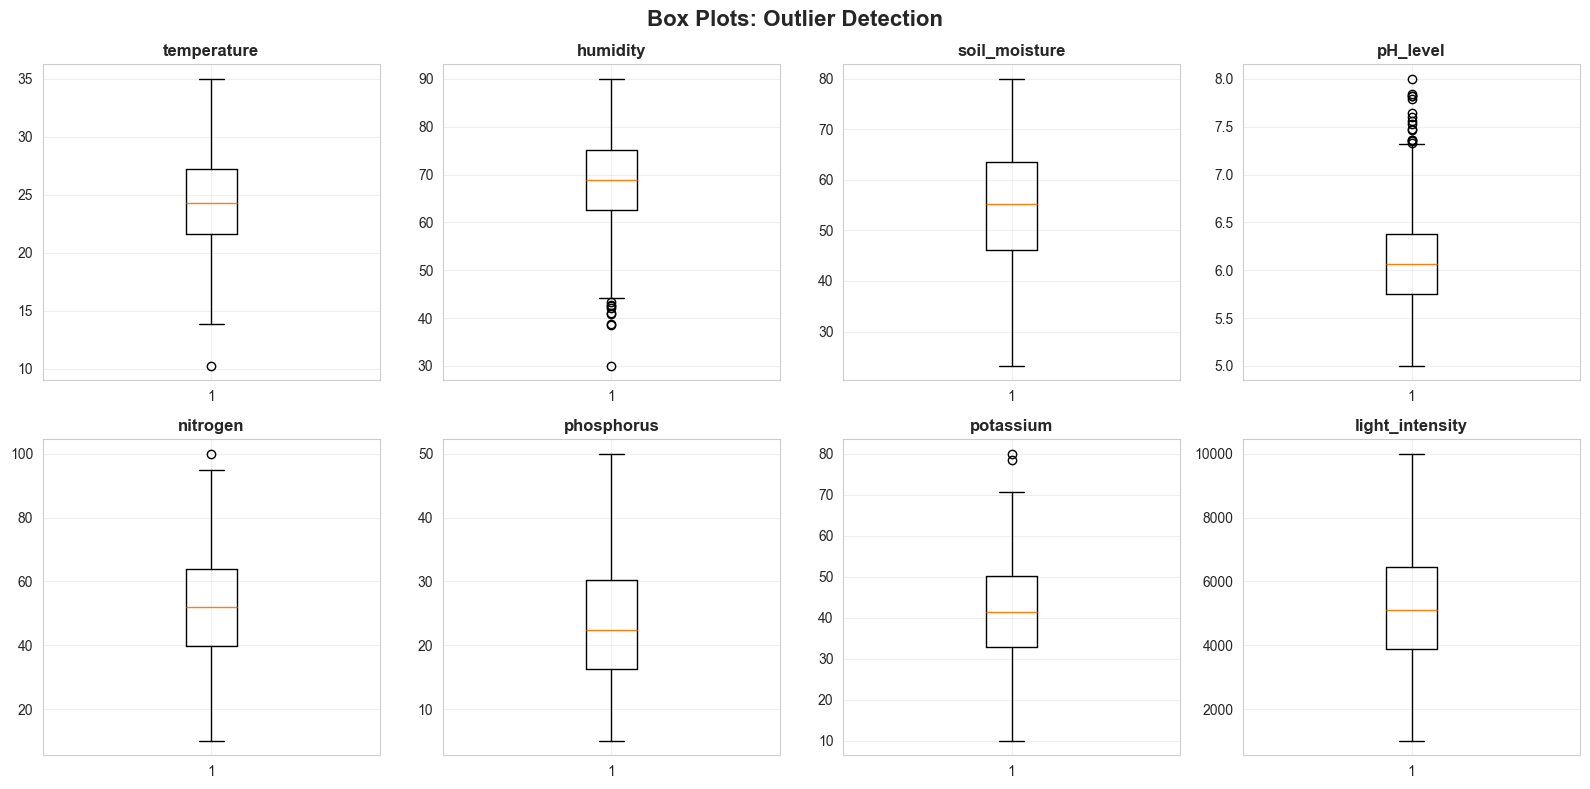

In [12]:
# Box plots to check for outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(df.columns[:-1]):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Box Plots: Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Written Summary of Data Exploration (200 words):**

### Task A2: Data Preprocessing (10 marks)

In [13]:
# Handle outliers (if any were identified in Part A)
# TODO: Based on your box plots above, decide if outlier handling is needed
# If outliers are present, choose and implement ONE approach:

#Option 1: Capping (clip extreme values)
for col in df.columns[:-1]:
     q99 = df[col].quantile(0.99)
     q01 = df[col].quantile(0.01)
     df[col] = df[col].clip(lower=q01, upper=q99)

# Option 2: Remove outlier rows (use IQR method)
#from scipy import stats
#z_scores = np.abs(stats.zscore(df.iloc[:, :-1]))
#df = df[(z_scores < 3).all(axis=1)]

# Option 3: No action needed (if outliers are valid/minimal)

# Implement your chosen approach here:
#for col in df.columns[:-1]:
#    Q1 = df[col].quantile(0.25)
#    Q3 = df[col].quantile(0.75)
#    IQR = Q3 - Q1
#    lower_bound = Q1 - 1.5 * IQR
#    upper_bound = Q3 + 1.5 * IQR
#    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
print("Outlier handling decision: Removed Outliers using IQR method")
print(f"Final dataset shape: {df.shape}")

Outlier handling decision: Removed Outliers using IQR method
Final dataset shape: (600, 9)


In [14]:
# Prepare features and target
X = df.drop('crop_health', axis=1)
y = df['crop_health']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeature names: {list(X.columns)}")

Features (X): (600, 8)
Target (y): (600,)

Feature names: ['temperature', 'humidity', 'soil_moisture', 'pH_level', 'nitrogen', 'phosphorus', 'potassium', 'light_intensity']


In [15]:
# Train-test split (stratified for balanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    stratify=y, 
    random_state=42
)

print("Train-Test Split:")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Train-Test Split:
Training set: 450 samples
Test set: 150 samples

Training set class distribution:
crop_health
Poor         116
Fair         113
Excellent    112
Good         109
Name: count, dtype: int64

Test set class distribution:
crop_health
Poor         38
Excellent    38
Good         37
Fair         37
Name: count, dtype: int64


In [16]:
# Feature scaling (StandardScaler)
scaler = StandardScaler()

# Fit on training data only (prevent data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Feature scaling completed!")
print("\nScaled feature statistics (training set):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

Feature scaling completed!

Scaled feature statistics (training set):
      temperature  humidity  soil_moisture  pH_level  nitrogen  phosphorus  \
mean       0.0000    0.0000         0.0000    0.0000   -0.0000     -0.0000   
std        1.0011    1.0011         1.0011    1.0011    1.0011      1.0011   

      potassium  light_intensity  
mean     0.0000           0.0000  
std      1.0011           1.0011  


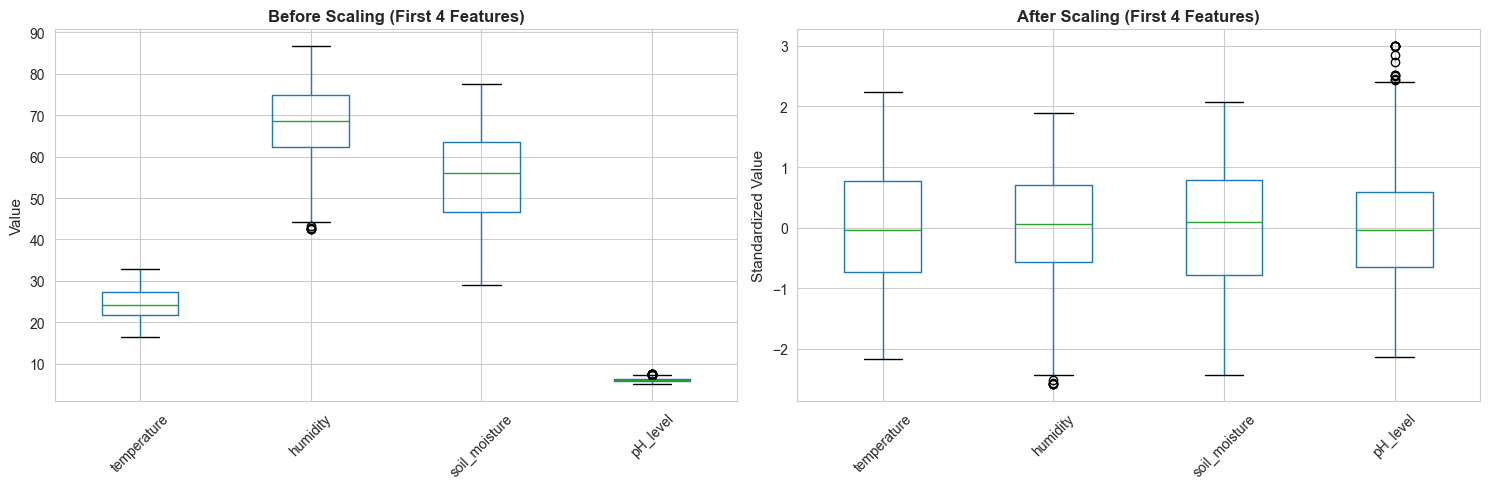


✓ All features now have mean ≈ 0 and std ≈ 1


In [17]:
# Visualize the effect of scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Before scaling
X_train.iloc[:, :4].boxplot(ax=ax1)
ax1.set_title('Before Scaling (First 4 Features)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# After scaling
X_train_scaled.iloc[:, :4].boxplot(ax=ax2)
ax2.set_title('After Scaling (First 4 Features)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Standardized Value', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")

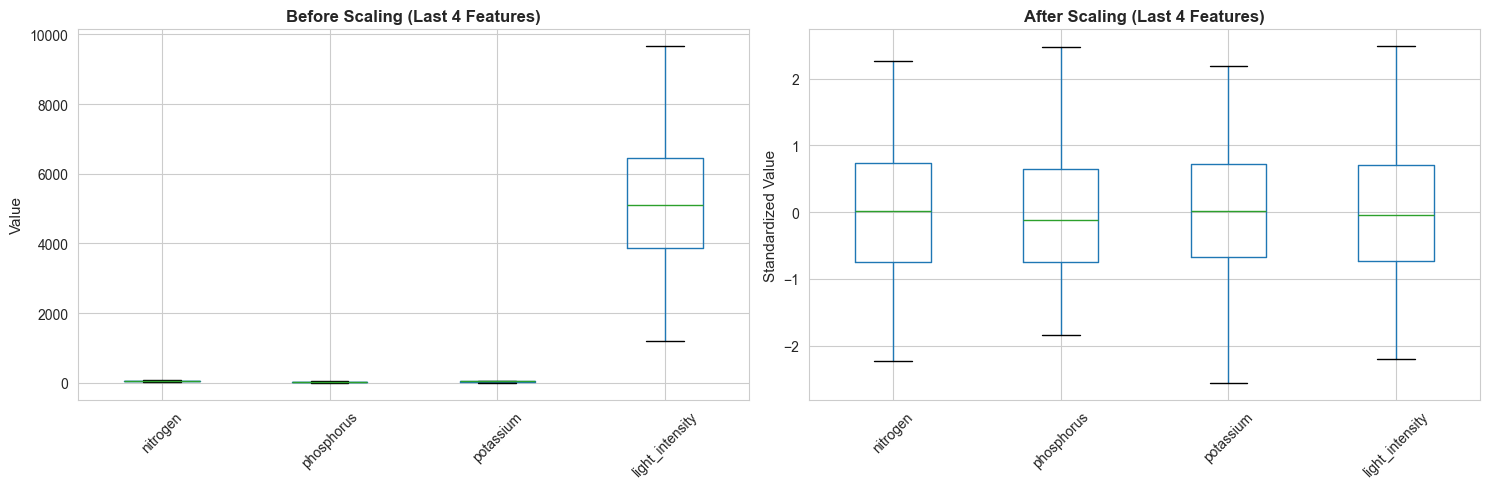


✓ All features now have mean ≈ 0 and std ≈ 1


In [18]:
# Visualize the effect of scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Before scaling
X_train.iloc[:, 4:].boxplot(ax=ax1)
ax1.set_title('Before Scaling (Last 4 Features)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# After scaling
X_train_scaled.iloc[:, 4:].boxplot(ax=ax2)
ax2.set_title('After Scaling (Last 4 Features)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Standardized Value', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")

**Written Explanation of Preprocessing (150 words):**

---

## Part B: Classification Analysis

### Task B1: Build Multiple Classifiers (15 marks)

#### Model 1: Decision Tree Classifier

In [19]:
# Decision Tree - Experiment with max_depth
# TODO: Test at least 3 different depth values
# Consider: shallow trees (3-5), medium trees (7-10), and unrestricted (None)

depths_to_try = [2,3,4,5,7,8,9,10,None]  # Add your depth values here
dt_results = []

for depth in depths_to_try:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_acc = dt.score(X_train_scaled, y_train)
    test_acc = dt.score(X_test_scaled, y_test)
    dt_results.append({
        'max_depth': depth,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

dt_results_df = pd.DataFrame(dt_results)
print("Decision Tree: Depth Experimentation")
print(dt_results_df)

Decision Tree: Depth Experimentation
   max_depth  train_accuracy  test_accuracy
0        2.0        0.648889       0.613333
1        3.0        0.837778       0.806667
2        4.0        0.880000       0.820000
3        5.0        0.917778       0.813333
4        7.0        0.955556       0.793333
5        8.0        0.964444       0.766667
6        9.0        0.984444       0.786667
7       10.0        0.993333       0.766667
8        NaN        1.000000       0.746667


In [20]:
# Select optimal depth and train final model
# TODO: Based on your results above, choose the best max_depth
# Consider: balance between training and test accuracy (avoid overfitting)

optimal_depth = 4  # Replace with your chosen depth

if optimal_depth is not None:
    dt_final = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
    dt_final.fit(X_train_scaled, y_train)
    y_pred_dt = dt_final.predict(X_test_scaled)
    
    print(f"Final Decision Tree (max_depth={optimal_depth}):")
    print(f"Training Accuracy: {dt_final.score(X_train_scaled, y_train):.4f}")

    print(f"Test Accuracy: {dt_final.score(X_test_scaled, y_test):.4f}")    
else:
    print("⚠ Please set optimal_depth to a value based on your experimentation above.")

Final Decision Tree (max_depth=4):
Training Accuracy: 0.8800
Test Accuracy: 0.8200


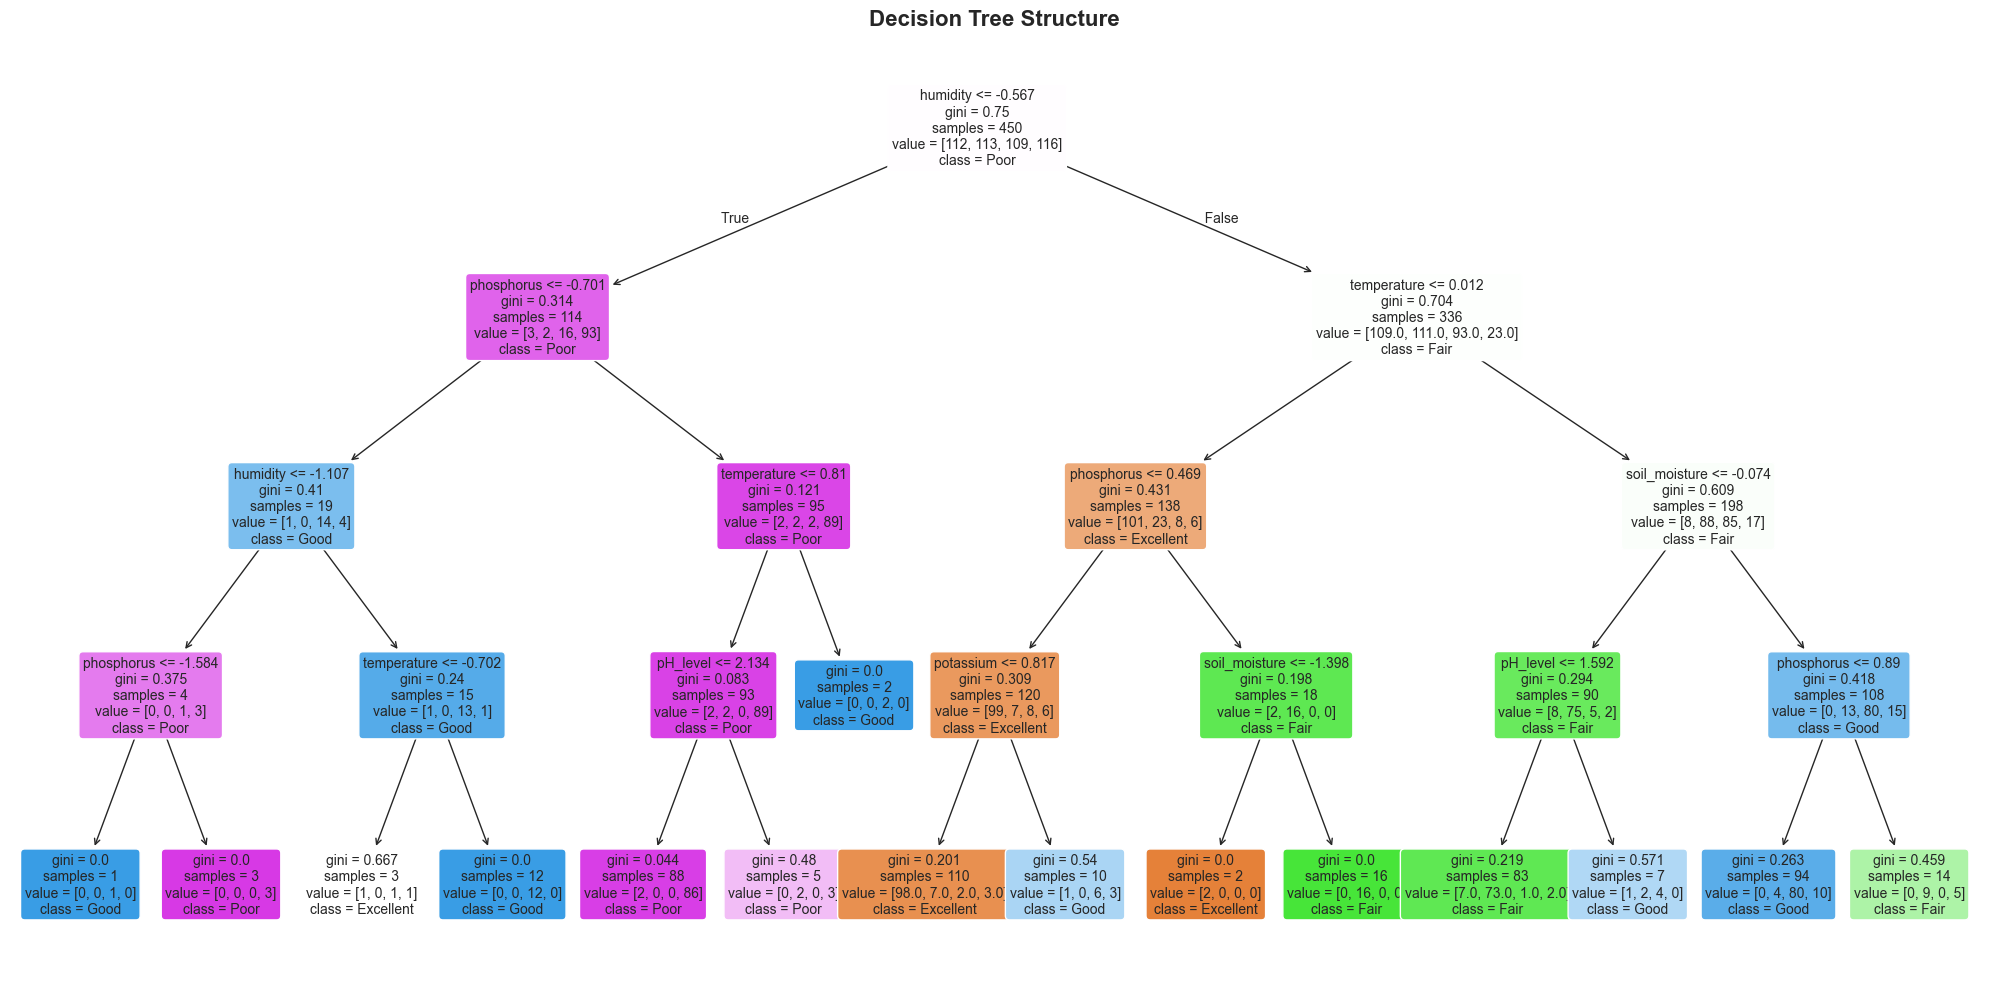

In [21]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_final, 
          feature_names=X.columns.tolist(),
          class_names=sorted(y.unique()),
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Model 2: Naive Bayes (GaussianNB)

In [22]:
# Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Classifier:")
print(f"Training Accuracy: {nb.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {nb.score(X_test_scaled, y_test):.4f}")

Naive Bayes Classifier:
Training Accuracy: 0.8644
Test Accuracy: 0.8467


#### Model 3: K-Nearest Neighbors (KNN)

In [23]:
# KNN - Test different K values
# TODO: Test at least 4 different K values
# Hint: Try both small values (3, 5) and larger values (7, 9, 11, etc.)

k_values = [3,4,5,7,9,11]  # Add your K values here
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)
    knn_results.append({
        'k': k,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

knn_results_df = pd.DataFrame(knn_results)
print("K-Nearest Neighbors: K Value Experimentation")
print(knn_results_df)

K-Nearest Neighbors: K Value Experimentation
    k  train_accuracy  test_accuracy
0   3        0.913333       0.853333
1   4        0.895556       0.840000
2   5        0.893333       0.866667
3   7        0.888889       0.873333
4   9        0.886667       0.880000
5  11        0.880000       0.873333


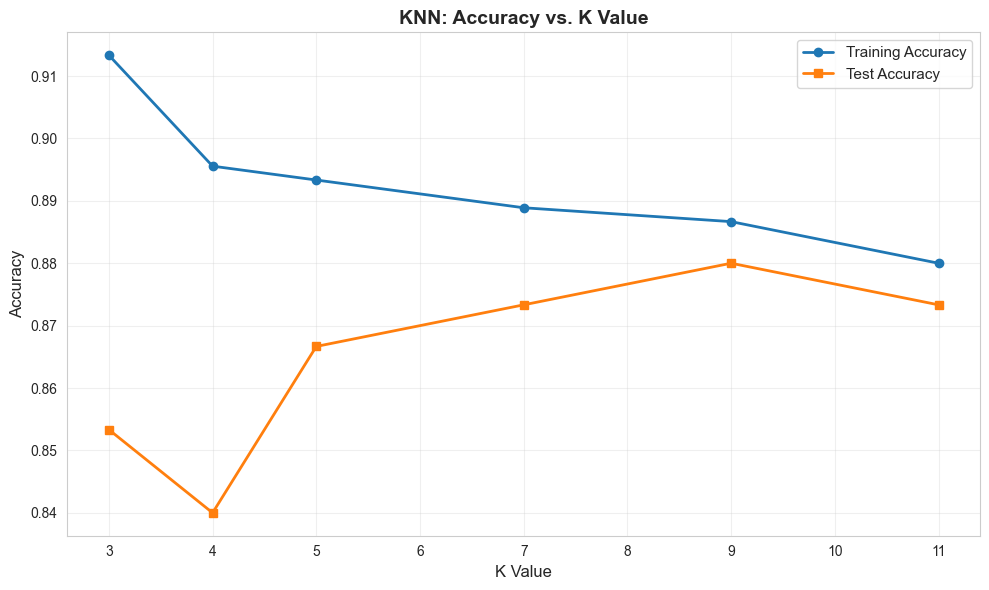

In [24]:
# Plot K vs. Accuracy
plt.figure(figsize=(10, 6))
plt.plot(knn_results_df['k'], knn_results_df['train_accuracy'], 
         marker='o', label='Training Accuracy', linewidth=2)
plt.plot(knn_results_df['k'], knn_results_df['test_accuracy'], 
         marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Accuracy vs. K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Select optimal K and train final model
# TODO: Based on your plot and results, choose the best K value
# Consider: Which K gives best test accuracy without overfitting?

optimal_k = 5  # Replace with your chosen K

if optimal_k is not None:
    knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
    knn_final.fit(X_train_scaled, y_train)
    y_pred_knn = knn_final.predict(X_test_scaled)
    
    print(f"Final KNN (k={optimal_k}):")
    print(f"Training Accuracy: {knn_final.score(X_train_scaled, y_train):.4f}")

    print(f"Test Accuracy: {knn_final.score(X_test_scaled, y_test):.4f}")    
else:
    print("⚠ Please set optimal_k to a value based on your experimentation above.")

Final KNN (k=5):
Training Accuracy: 0.8933
Test Accuracy: 0.8667


In [26]:
# Select optimal K and train final model
# TODO: Based on your plot and results, choose the best K value
# Consider: Which K gives best test accuracy without overfitting?

optimal_k = 9  # Replace with your chosen K

if optimal_k is not None:
    knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
    knn_final.fit(X_train_scaled, y_train)
    y_pred_knn = knn_final.predict(X_test_scaled)
    
    print(f"Final KNN (k={optimal_k}):")
    print(f"Training Accuracy: {knn_final.score(X_train_scaled, y_train):.4f}")

    print(f"Test Accuracy: {knn_final.score(X_test_scaled, y_test):.4f}")    
else:
    print("⚠ Please set optimal_k to a value based on your experimentation above.")

Final KNN (k=9):
Training Accuracy: 0.8867
Test Accuracy: 0.8800


### Task B2: Evaluate and Compare Classifiers (15 marks)

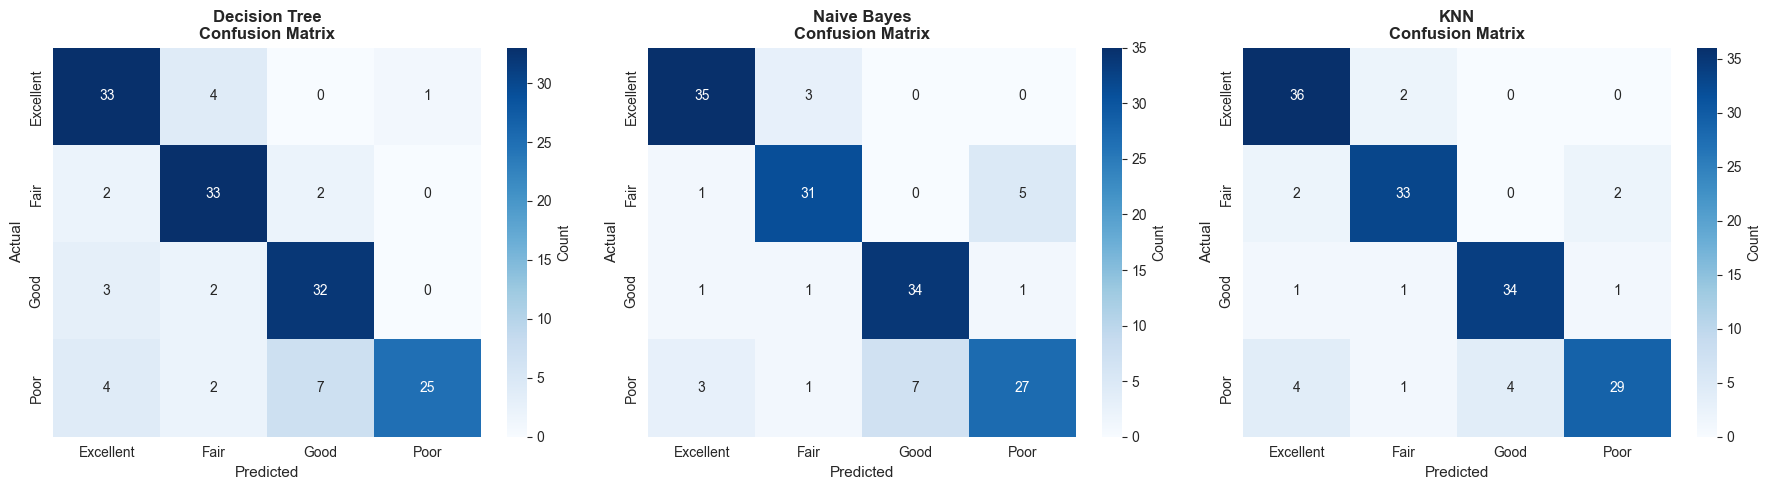

In [27]:
# Confusion Matrices for all three models
models = [
    ('Decision Tree', y_pred_dt),
    ('Naive Bayes', y_pred_nb),
    ('KNN', y_pred_knn)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=sorted(y.unique()),
                yticklabels=sorted(y.unique()),
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()

In [28]:
# Calculate all metrics for comparison
def calculate_metrics(y_true, y_pred, model_name):
    """Calculate comprehensive metrics for a classifier."""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro'),
        'F1-Score (macro)': f1_score(y_true, y_pred, average='macro')
    }

# Collect metrics for all models
comparison_metrics = [
    calculate_metrics(y_test, y_pred_dt, 'Decision Tree'),
    calculate_metrics(y_test, y_pred_nb, 'Naive Bayes'),
    calculate_metrics(y_test, y_pred_knn, 'K-Nearest Neighbors')
]

comparison_df = pd.DataFrame(comparison_metrics)
comparison_df = comparison_df.round(4)

print("Classification Model Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

Classification Model Comparison:
              Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
      Decision Tree    0.8200             0.8332          0.8208            0.8182
        Naive Bayes    0.8467             0.8459          0.8471            0.8448
K-Nearest Neighbors    0.8800             0.8825          0.8803            0.8790


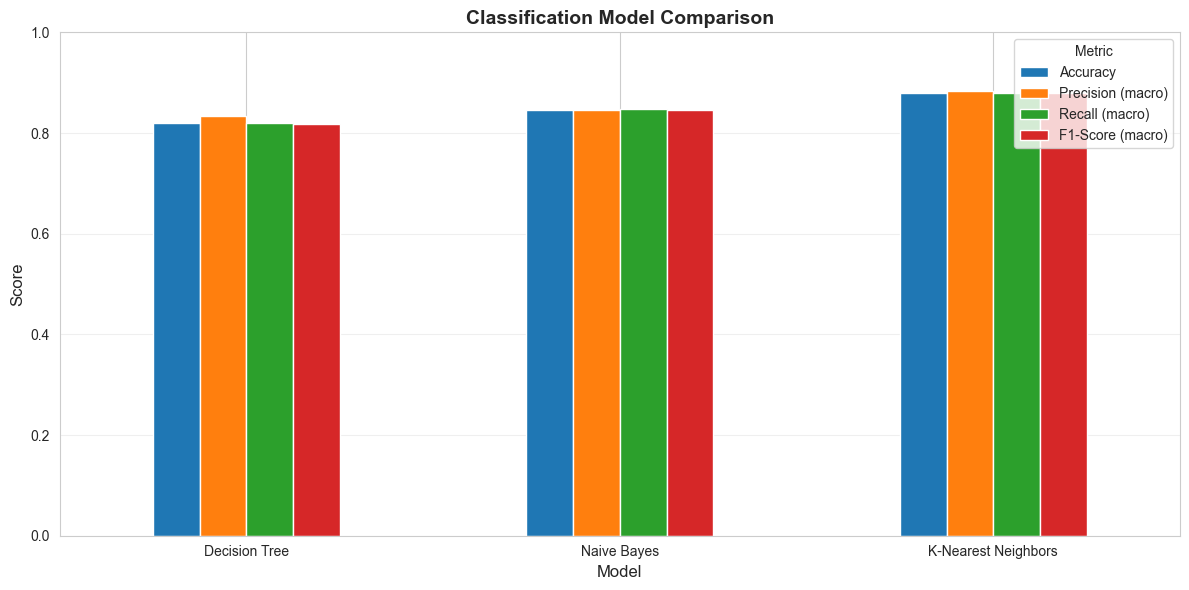

In [29]:
# Visualize metric comparison
comparison_plot = comparison_df.set_index('Model')
comparison_plot.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Classification Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Metric', fontsize=10)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [30]:
# Detailed classification reports
print("Detailed Classification Reports:")
print("=" * 80)

for name, y_pred in models:
    print(f"\n{name}:")
    print("-" * 80)
    print(classification_report(y_test, y_pred, target_names=sorted(y.unique())))
    print("-" * 80)

Detailed Classification Reports:

Decision Tree:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   Excellent       0.79      0.87      0.82        38
        Fair       0.80      0.89      0.85        37
        Good       0.78      0.86      0.82        37
        Poor       0.96      0.66      0.78        38

    accuracy                           0.82       150
   macro avg       0.83      0.82      0.82       150
weighted avg       0.83      0.82      0.82       150

--------------------------------------------------------------------------------

Naive Bayes:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

   Excellent       0.88      0.92      0.90        38
        Fair       0.86      0.84      0.85        37
        Good       0.83      0.92      0.87        37
        Poor       0.82      0.71      0.7

**Analysis of Model Comparison (300 words):**

### Task B3: Model Interpretation (10 marks)

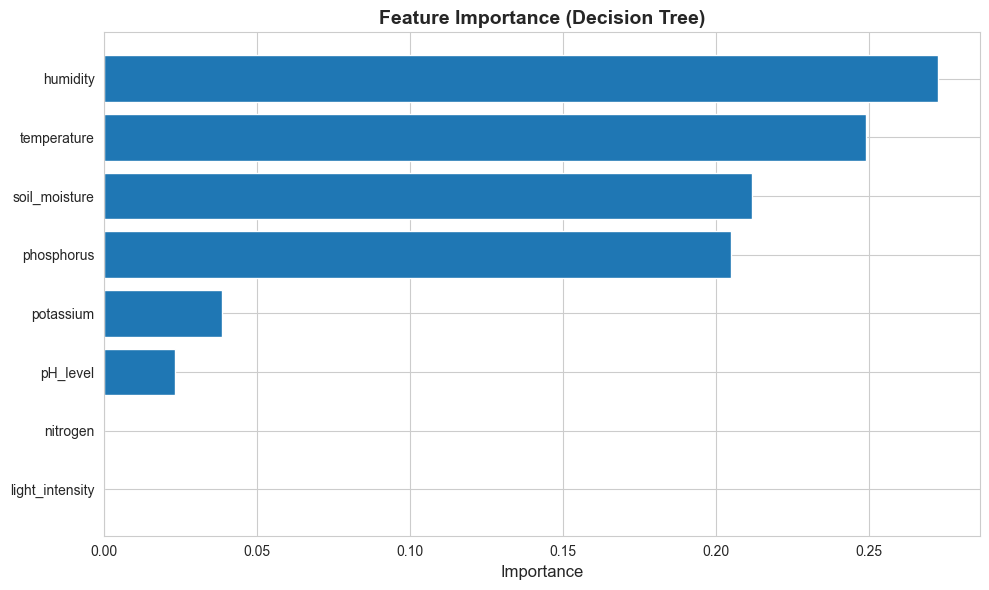

Feature Importance Ranking:
           Feature  Importance
1         humidity    0.272624
0      temperature    0.249119
2    soil_moisture    0.211845
5       phosphorus    0.204763
6        potassium    0.038478
3         pH_level    0.023172
4         nitrogen    0.000000
7  light_intensity    0.000000


In [31]:
# Feature importance (for Decision Tree)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_final.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance (Decision Tree)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
print(feature_importance)

In [32]:
# Error analysis - examine misclassified instances
# TODO: Based on your comparison above, identify your best-performing model
# Replace y_pred_dt with the predictions from your best model

best_model_predictions = y_pred_knn  # Change to y_pred_nb or y_pred_knn if they performed better

# Identify misclassified instances
misclassified_idx = y_test != best_model_predictions
misclassified_df = X_test[misclassified_idx].copy()
misclassified_df['Actual'] = y_test[misclassified_idx]
misclassified_df['Predicted'] = best_model_predictions[misclassified_idx]

print(f"Total misclassified instances: {misclassified_idx.sum()}")
print(f"Percentage: {misclassified_idx.sum() / len(y_test) * 100:.2f}%")

print("\nMisclassification patterns:")
print(misclassified_df[['Actual', 'Predicted']].value_counts())

Total misclassified instances: 18
Percentage: 12.00%

Misclassification patterns:
Actual     Predicted
Poor       Good         4
           Excellent    4
Excellent  Fair         2
Fair       Excellent    2
           Poor         2
Good       Fair         1
           Excellent    1
           Poor         1
Poor       Fair         1
Name: count, dtype: int64


In [33]:
# Examine specific misclassified examples
print("Examples of misclassified instances:")
print(misclassified_df.head(10))

Examples of misclassified instances:
     temperature  humidity  soil_moisture  pH_level  nitrogen  phosphorus  \
213        26.18      75.1           53.5      6.05      47.6        23.3   
592        21.02      65.3           66.1      5.46      60.8        22.5   
327        22.61      52.7           74.0      6.44      69.0         5.0   
358        26.43      74.2           39.9      6.45      50.5        11.8   
187        21.49      66.5           51.3      5.99      52.9        27.2   
321        23.36      62.5           51.0      6.65      42.2        24.7   
568        19.35      73.2           55.7      6.41      71.8        21.7   
77         27.79      69.6           44.5      6.67      28.7        35.5   
522        21.88      67.5           62.0      6.10      60.2        36.4   
111        21.38      70.2           54.9      5.32      61.2        18.9   

     potassium  light_intensity     Actual  Predicted  
213       39.2           4544.0  Excellent       Fair  
592

**Model Interpretation and Recommendations (300 words):**

---

## Part C: Clustering Analysis

**Note:** For clustering, we ignore the `crop_health` label and treat data as unlabeled.

### Task C1: Determine Optimal Number of Clusters (15 marks)

In [34]:
# Prepare data for clustering (use scaled features, ignore labels)
X_clustering = X_train_scaled.values

print(f"Clustering dataset shape: {X_clustering.shape}")

Clustering dataset shape: (450, 8)


In [35]:
# Test different K values
k_range = range(2, 11)
wcss_scores = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clustering)
    
    wcss_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering, labels))
    calinski_scores.append(calinski_harabasz_score(X_clustering, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_clustering, labels))

print("Optimal K evaluation completed.")

Optimal K evaluation completed.


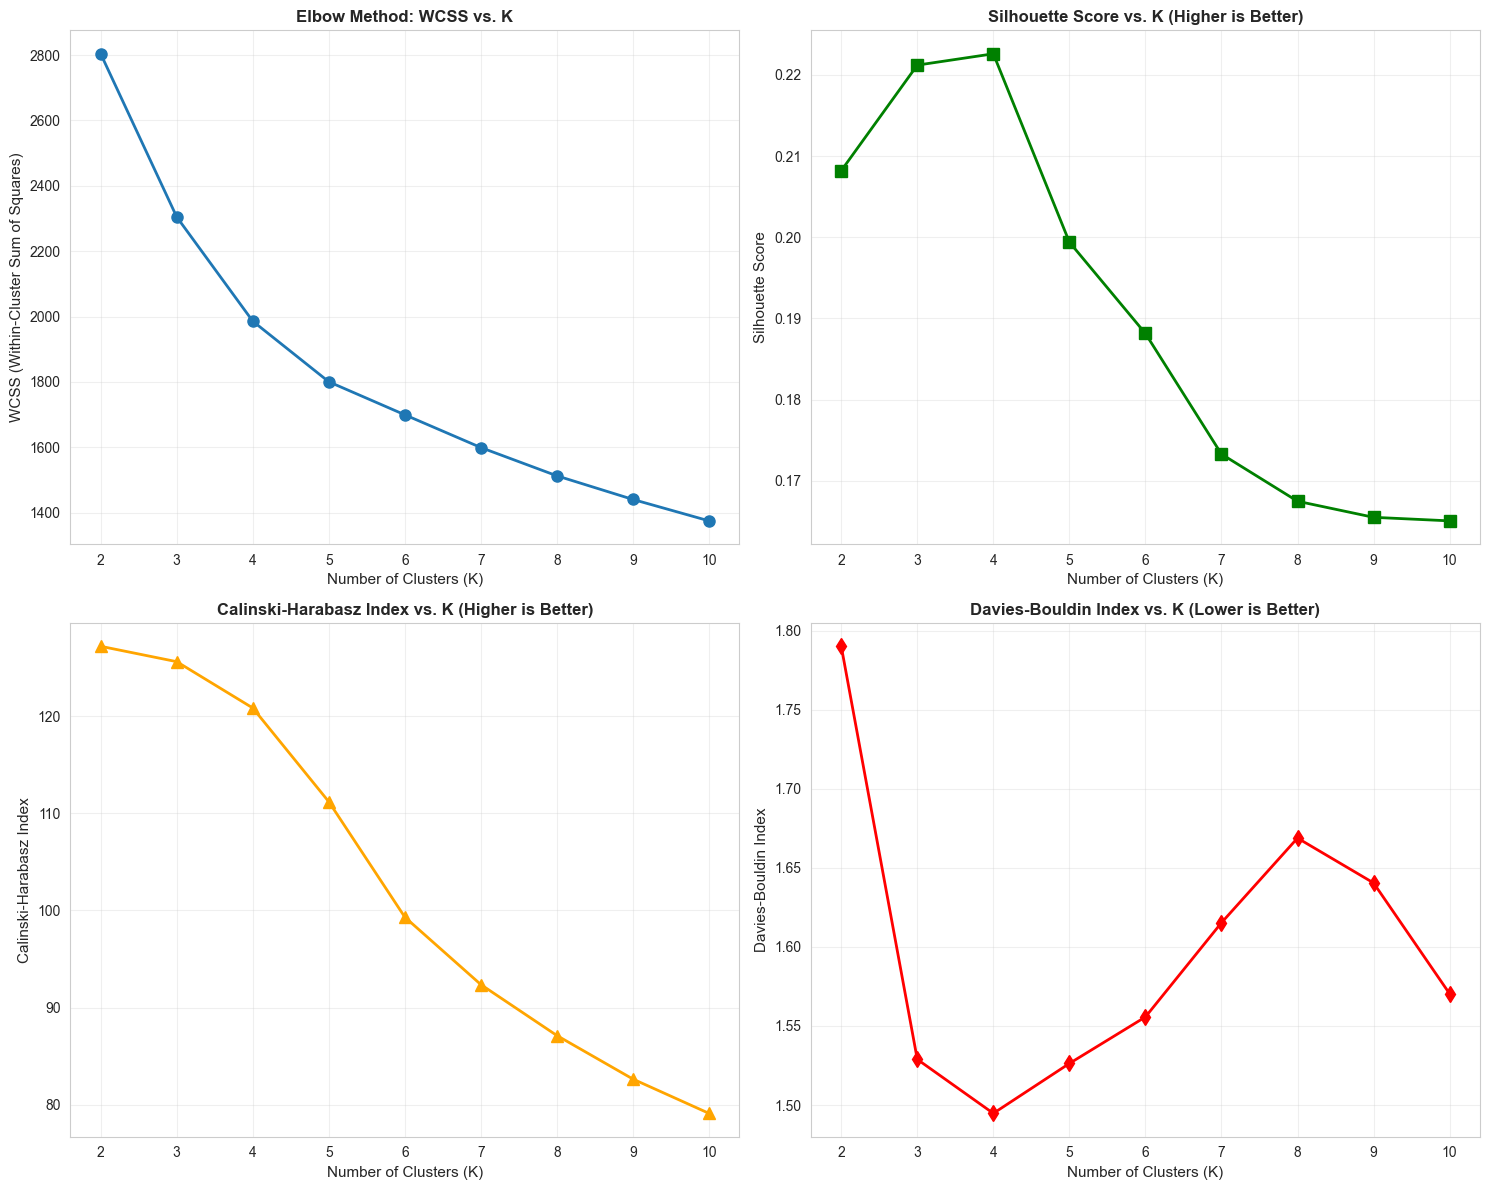

In [36]:
# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# WCSS (Elbow Method)
axes[0, 0].plot(k_range, wcss_scores, marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0, 0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=11)
axes[0, 0].set_title('Elbow Method: WCSS vs. K', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score vs. K (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz Index
axes[1, 0].plot(k_range, calinski_scores, marker='^', linewidth=2, markersize=8, color='orange')
axes[1, 0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[1, 0].set_title('Calinski-Harabasz Index vs. K (Higher is Better)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin Index
axes[1, 1].plot(k_range, davies_bouldin_scores, marker='d', linewidth=2, markersize=8, color='red')
axes[1, 1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 1].set_title('Davies-Bouldin Index vs. K (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
# Summary table
optimal_k_df = pd.DataFrame({
    'K': list(k_range),
    'WCSS': wcss_scores,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_bouldin_scores
})

print("Optimal K Analysis Summary:")
print(optimal_k_df.round(4))

Optimal K Analysis Summary:
    K       WCSS  Silhouette  Calinski-Harabasz  Davies-Bouldin
0   2  2803.9351      0.2082           127.1916          1.7900
1   3  2304.7268      0.2212           125.6086          1.5289
2   4  1985.8388      0.2226           120.8416          1.4948
3   5  1800.4913      0.1994           111.1893          1.5263
4   6  1699.4164      0.1881            99.3116          1.5557
5   7  1599.2401      0.1733            92.3706          1.6153
6   8  1512.7303      0.1675            87.1247          1.6688
7   9  1440.4598      0.1655            82.6435          1.6405
8  10  1374.9485      0.1651            79.1159          1.5704


**Optimal K Selection and Justification (200 words):**

### Task C2: Apply Clustering Algorithms (15 marks)

#### Algorithm 1: K-Means

In [38]:
# Apply K-Means with optimal K
# TODO: Set your optimal K based on the analysis you completed above
# This should match the value you justified in your written analysis

optimal_k = 4 # Replace with your chosen optimal K

if optimal_k is not None:
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    kmeans_labels = kmeans_final.fit_predict(X_clustering)
    
    print(f"K-Means Clustering (K={optimal_k}):")
    print(f"Cluster sizes: {np.bincount(kmeans_labels)}")
    print(f"WCSS: {kmeans_final.inertia_:.2f}")

else:    print("⚠ Please set optimal_k based on your analysis in Task C1.")

K-Means Clustering (K=4):
Cluster sizes: [104 111 135 100]
WCSS: 1985.84


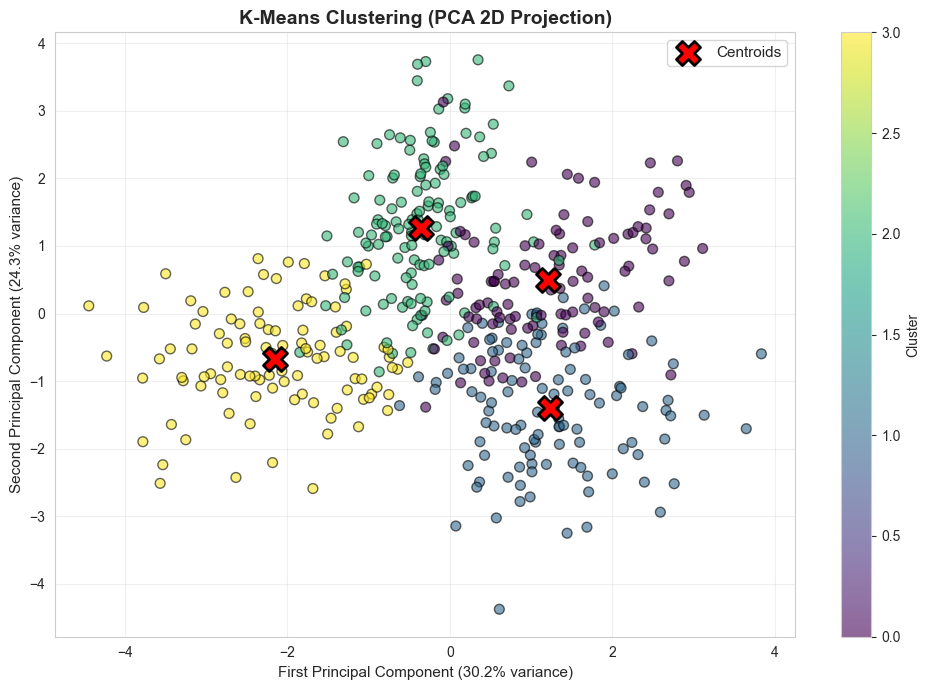


Variance explained by first 2 PCs: 54.5%


In [39]:
# Visualize clusters using PCA for 2D projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=kmeans_labels, cmap='viridis', 
                     alpha=0.6, edgecolors='black', s=50)

# Plot centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=300, c='red', edgecolors='black', linewidths=2,
           label='Centroids')

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title('K-Means Clustering (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVariance explained by first 2 PCs: {sum(pca.explained_variance_ratio_):.1%}")

#### Algorithm 2: Hierarchical Clustering

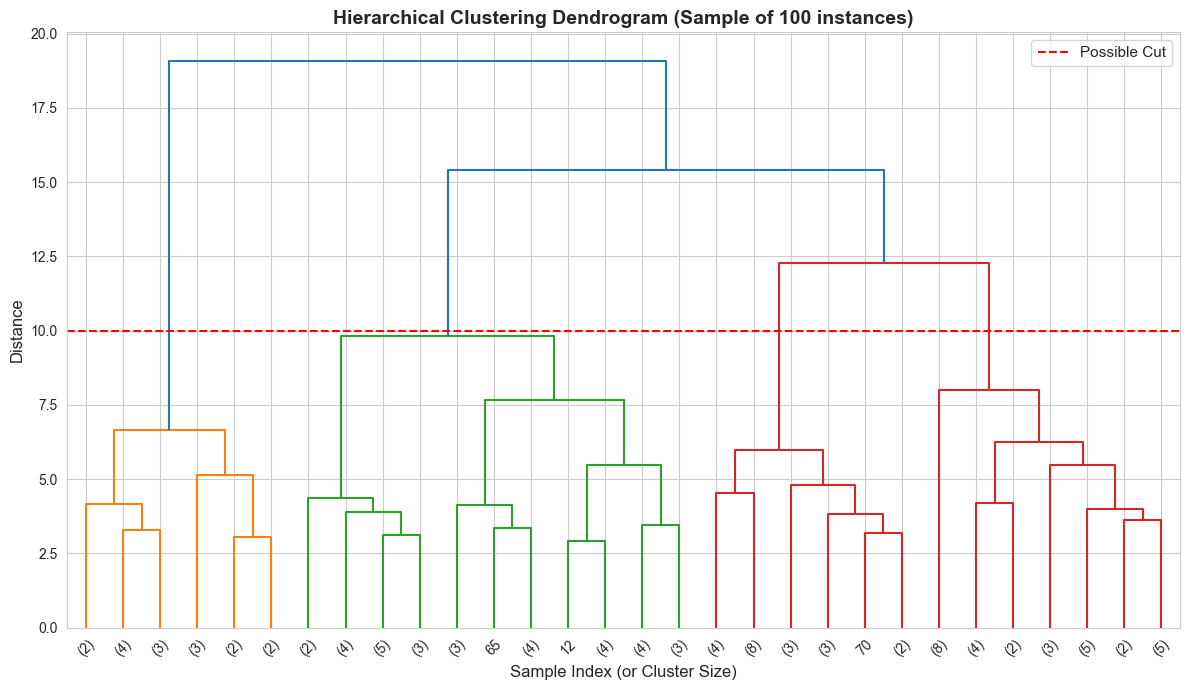

In [40]:
# Hierarchical clustering with dendrogram
# Note: Computing dendrogram for all samples may be slow, so we sample
sample_size = min(100, len(X_clustering))
sample_indices = np.random.choice(len(X_clustering), sample_size, replace=False)
X_sample = X_clustering[sample_indices]

# Compute linkage
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.xlabel('Sample Index (or Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title(f'Hierarchical Clustering Dendrogram (Sample of {sample_size} instances)', 
          fontsize=14, fontweight='bold')
plt.axhline(y=10, color='r', linestyle='--', label='Possible Cut')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [41]:
# Apply hierarchical clustering to full dataset
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_clustering)

print(f"Hierarchical Clustering (K={optimal_k}):")
print(f"Cluster sizes: {np.bincount(hierarchical_labels)}")

Hierarchical Clustering (K=4):
Cluster sizes: [136 130  93  91]


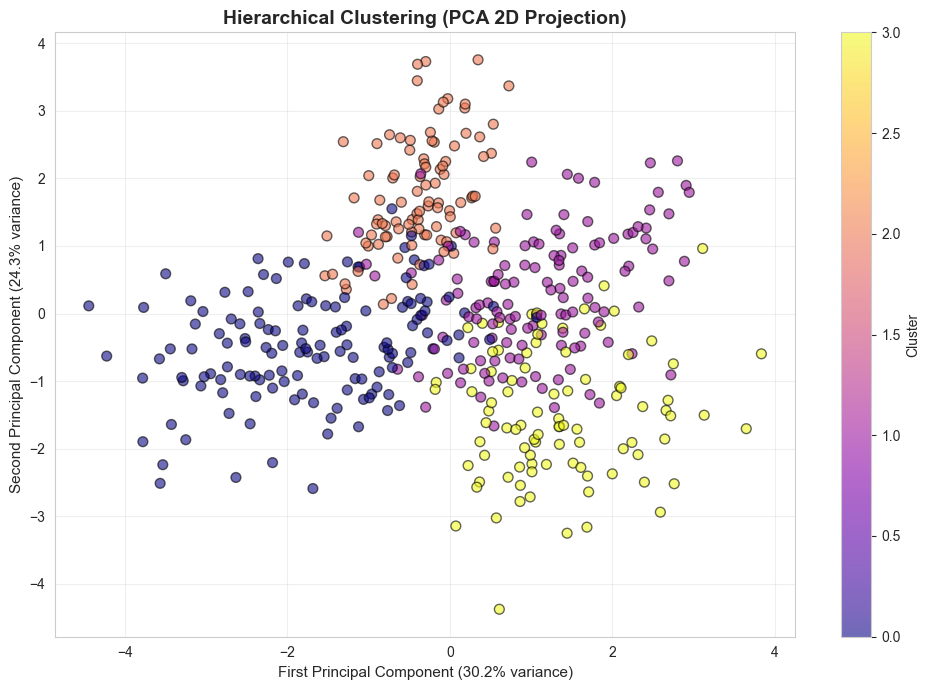

In [42]:
# Visualize hierarchical clustering
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=hierarchical_labels, cmap='plasma', 
                     alpha=0.6, edgecolors='black', s=50)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title('Hierarchical Clustering (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Algorithm 3: DBSCAN

In [43]:
# DBSCAN - Experiment with parameters
# TODO: You need to find good values for eps and min_samples
# Start with these suggestions, then adjust:
# - eps: Try values between 0.3 and 2.0 (controls neighborhood size)
# - min_samples: Try values between 3 and 10 (minimum points to form cluster)
# Run this cell multiple times with different values until you get meaningful clusters

eps_value = 1.5      # Replace with your chosen eps
min_samples_value = 3 # Replace with your chosen min_samples

if eps_value is not None and min_samples_value is not None:
    dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
    dbscan_labels = dbscan.fit_predict(X_clustering)
    
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise = list(dbscan_labels).count(-1)
    
    print(f"DBSCAN Clustering (eps={eps_value}, min_samples={min_samples_value}):")
    print(f"Number of clusters found: {n_clusters}")
    print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
    
    if n_clusters > 0:
        cluster_sizes = np.bincount(dbscan_labels[dbscan_labels >= 0])
        print(f"Cluster sizes: {cluster_sizes}")
    else:
        print("⚠ No clusters found! Try adjusting eps and min_samples.")
else:
    print("⚠ Please set both eps_value and min_samples_value to experiment with DBSCAN.")

DBSCAN Clustering (eps=1.5, min_samples=3):
Number of clusters found: 7
Number of noise points: 55 (12.2%)
Cluster sizes: [376   3   4   3   3   3   3]


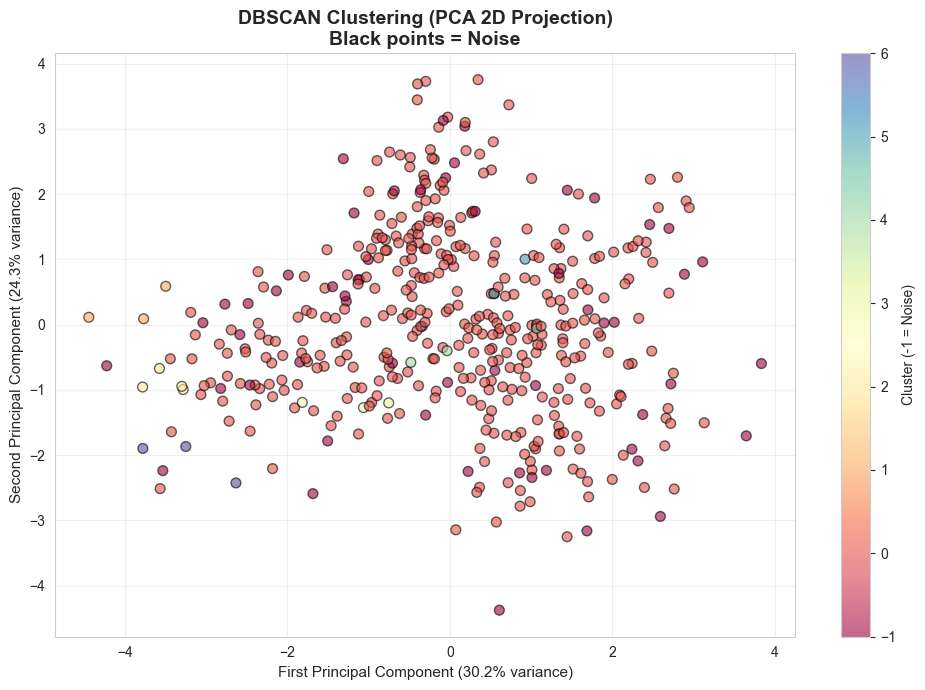

In [44]:
# Visualize DBSCAN
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=dbscan_labels, cmap='Spectral', 
                     alpha=0.6, edgecolors='black', s=50)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
plt.title('DBSCAN Clustering (PCA 2D Projection)\nBlack points = Noise', 
          fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task C3: Evaluate and Interpret Clusters (10 marks)

In [45]:
# Quantitative comparison of clustering methods
clustering_comparison = []

# K-Means
clustering_comparison.append({
    'Method': 'K-Means',
    'Silhouette': silhouette_score(X_clustering, kmeans_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_clustering, kmeans_labels),
    'Davies-Bouldin': davies_bouldin_score(X_clustering, kmeans_labels),
    'Clusters': optimal_k,
    'Noise Points': 0
})

# Hierarchical
clustering_comparison.append({
    'Method': 'Hierarchical',
    'Silhouette': silhouette_score(X_clustering, hierarchical_labels),
    'Calinski-Harabasz': calinski_harabasz_score(X_clustering, hierarchical_labels),
    'Davies-Bouldin': davies_bouldin_score(X_clustering, hierarchical_labels),
    'Clusters': optimal_k,
    'Noise Points': 0
})

# DBSCAN (only if found clusters)
if n_clusters > 1:
    # Filter out noise points for metric calculation
    non_noise_mask = dbscan_labels >= 0
    X_no_noise = X_clustering[non_noise_mask]
    labels_no_noise = dbscan_labels[non_noise_mask]
    
    clustering_comparison.append({
        'Method': 'DBSCAN',
        'Silhouette': silhouette_score(X_no_noise, labels_no_noise),
        'Calinski-Harabasz': calinski_harabasz_score(X_no_noise, labels_no_noise),
        'Davies-Bouldin': davies_bouldin_score(X_no_noise, labels_no_noise),
        'Clusters': n_clusters,
        'Noise Points': n_noise
    })

clustering_comparison_df = pd.DataFrame(clustering_comparison)
clustering_comparison_df = clustering_comparison_df.round(4)

print("Clustering Method Comparison:")
print("=" * 80)
print(clustering_comparison_df.to_string(index=False))
print("=" * 80)

Clustering Method Comparison:
      Method  Silhouette  Calinski-Harabasz  Davies-Bouldin  Clusters  Noise Points
     K-Means      0.2226           120.8416          1.4948         4             0
Hierarchical      0.1898           103.8549          1.6043         4             0
      DBSCAN     -0.0769             7.1009          1.1087         7            55


In [46]:
# Cluster profiling (using K-Means as example)
# Create DataFrame with cluster assignments
clustering_results = X_train_scaled.copy()
clustering_results['Cluster'] = kmeans_labels

# Calculate mean values per cluster
cluster_profiles = clustering_results.groupby('Cluster').mean()

print("K-Means Cluster Profiles:")
print("=" * 80)
print(cluster_profiles.round(3))
print("=" * 80)

print("\nCluster Sizes:")
print(clustering_results['Cluster'].value_counts().sort_index())

K-Means Cluster Profiles:
         temperature  humidity  soil_moisture  pH_level  nitrogen  phosphorus  \
Cluster                                                                         
0              0.795     0.944         -0.762     0.021    -0.295       0.590   
1             -0.770     0.513         -0.728    -0.229     1.107      -0.636   
2              0.644    -0.145          0.776    -0.086    -0.275      -0.480   
3             -0.841    -1.355          0.553     0.348    -0.551       0.739   

         potassium  light_intensity  
Cluster                              
0           -0.791           -0.110  
1           -0.719            0.381  
2            0.612           -0.900  
3            0.795            0.906  

Cluster Sizes:
Cluster
0    104
1    111
2    135
3    100
Name: count, dtype: int64


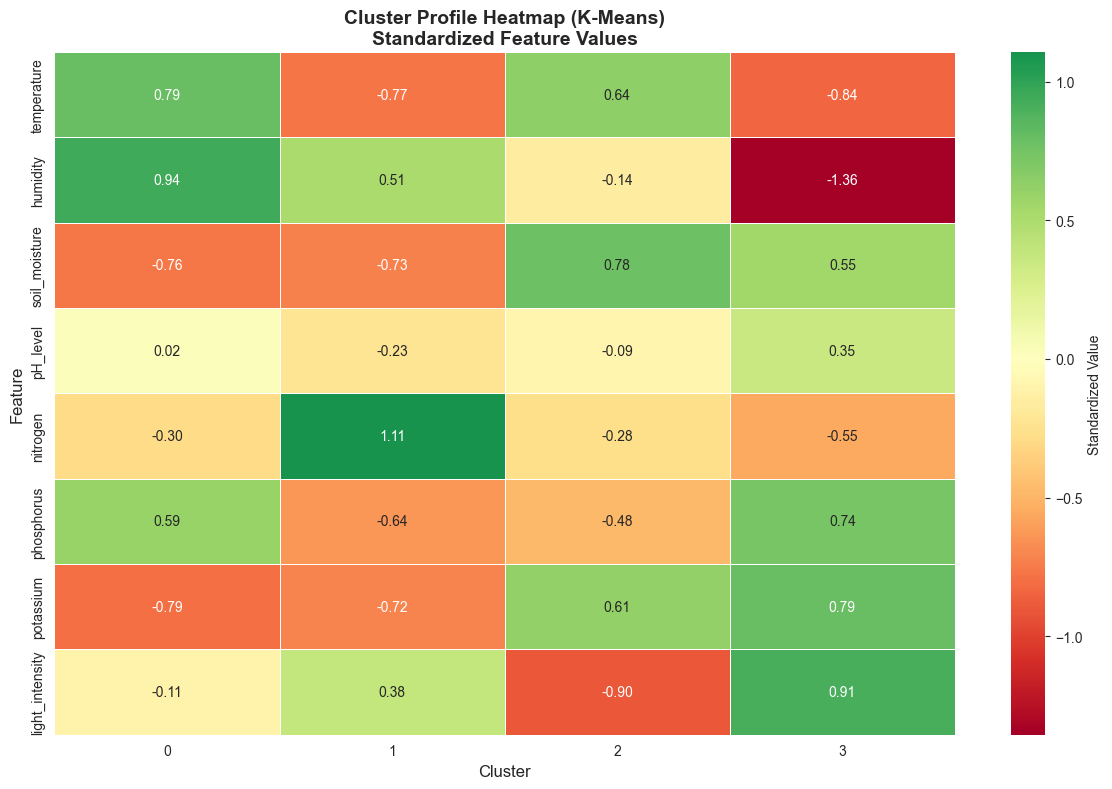

In [47]:
# Visualize cluster profiles
cluster_profiles_T = cluster_profiles.T

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles_T, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, linewidths=0.5, cbar_kws={'label': 'Standardized Value'})
plt.title('Cluster Profile Heatmap (K-Means)\nStandardized Feature Values', 
          fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

Cluster vs. True Crop Health Cross-Tabulation:
True_Health  Excellent  Fair  Good  Poor
Cluster                                 
0                   10    88     4     2
1                   95    11     2     3
2                    4     8    98    25
3                    3     6     5    86


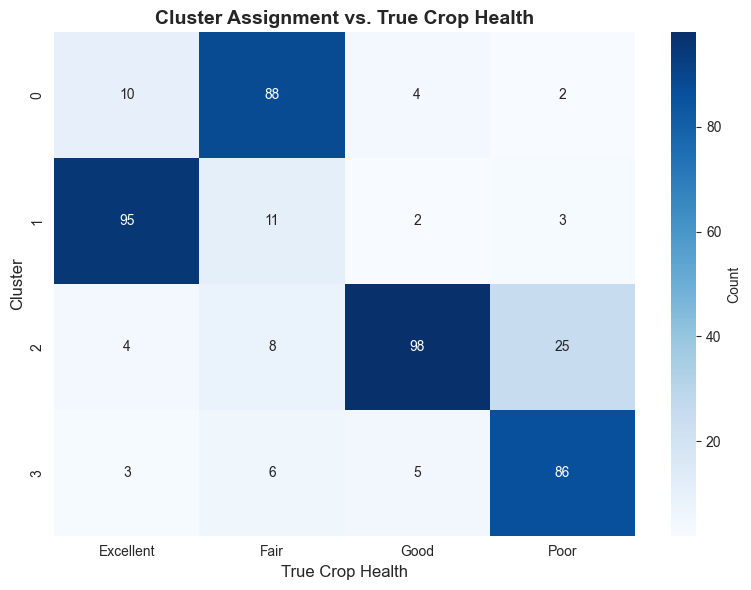

In [48]:
# Compare clusters with true labels (crop_health)
comparison_df = pd.DataFrame({
    'Cluster': kmeans_labels,
    'True_Health': y_train.values
})

# Cross-tabulation
crosstab = pd.crosstab(comparison_df['Cluster'], comparison_df['True_Health'])
print("Cluster vs. True Crop Health Cross-Tabulation:")
print(crosstab)

# Visualize as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Count'})
plt.title('Cluster Assignment vs. True Crop Health', fontsize=14, fontweight='bold')
plt.xlabel('True Crop Health', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.show()

In [49]:
# Calculate clustering "accuracy" with best label mapping
from scipy.optimize import linear_sum_assignment

# Create confusion matrix
confusion = crosstab.values

# Find optimal assignment (maximize diagonal sum)
row_ind, col_ind = linear_sum_assignment(-confusion)

# Calculate accuracy with best mapping
clustering_accuracy = confusion[row_ind, col_ind].sum() / len(kmeans_labels)

print(f"\nClustering 'Accuracy' (with optimal label mapping): {clustering_accuracy:.2%}")
print(f"\nOptimal cluster-to-label mapping:")
health_labels = sorted(y_train.unique())
for cluster, label_idx in zip(row_ind, col_ind):
    print(f"  Cluster {cluster} → {health_labels[label_idx]}")


Clustering 'Accuracy' (with optimal label mapping): 81.56%

Optimal cluster-to-label mapping:
  Cluster 0 → Fair
  Cluster 1 → Excellent
  Cluster 2 → Good
  Cluster 3 → Poor


**Cluster Interpretation and Analysis (300 words):**